Load DataSet

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student-por.csv to student-por.csv


In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Summer Internship/Week-2/student-por.csv')

Missing Values Analysis:Compute the absolute and percentage missing for every column.




In [ ]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({
 "Missing Count": missing,
 "Missing %": round(missing / len(df) * 100, 2)
})
missing_df.sort_values(by="Missing Count", ascending=False)


,Missing Count,Missing %
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


Missing Values Visualisation

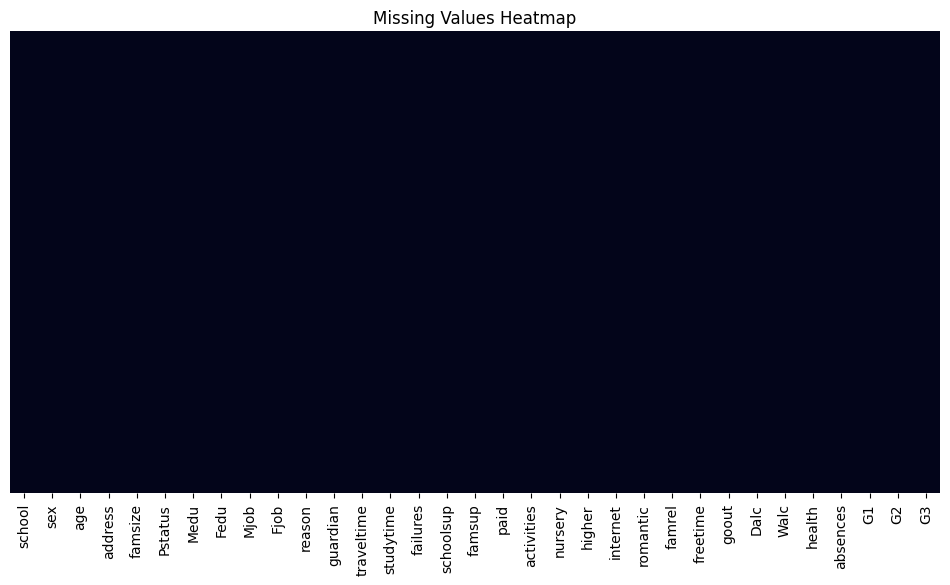

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

Handle Missing Values:Numerical Columns — Fill with Median


In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Features:")
print(list(numeric_cols))

print("\nCategorical Features:")
print(list(categorical_cols))

Numerical Features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical Features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [ ]:
for col in numeric_cols:
 df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_854/1324120409.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Handle Missing Values:Categorical Columns — Fill with Mode

In [ ]:
for col in categorical_cols:
 df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_854/1086946666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Duplicate Records

In [ ]:
print('Duplicates found:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates found: 0


Outlier Detection

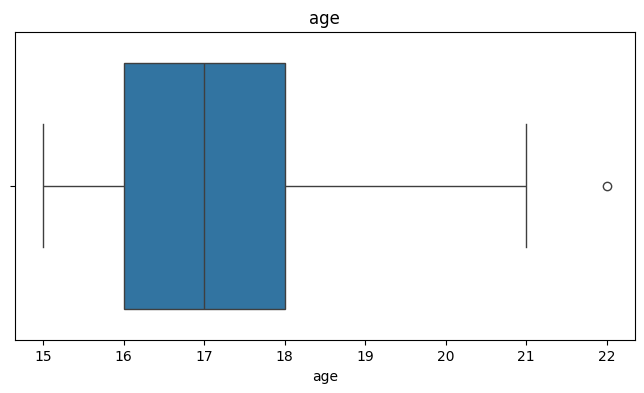

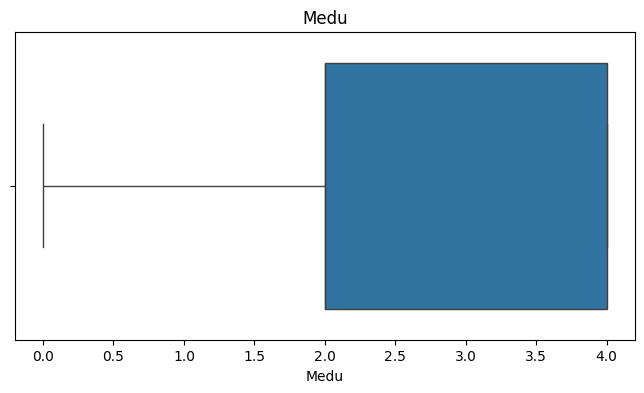

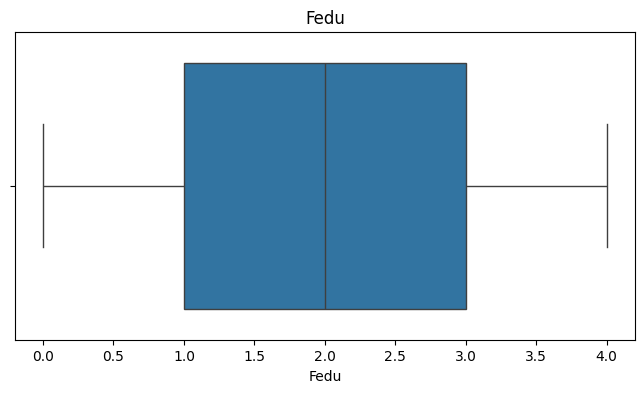

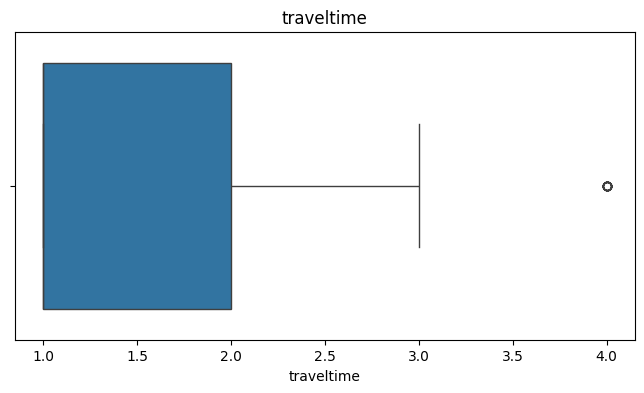

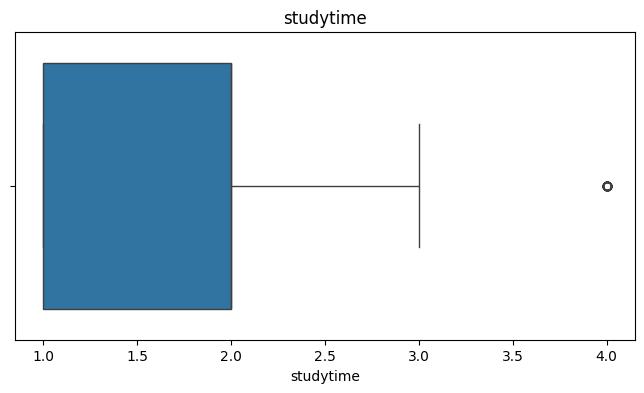

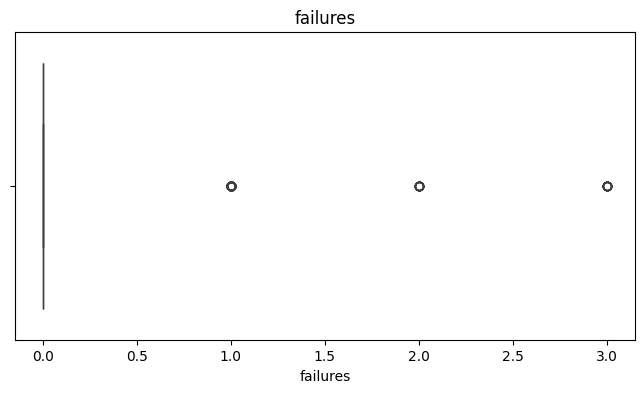

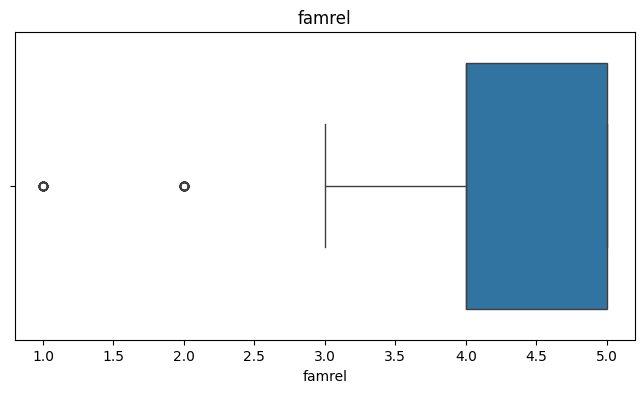

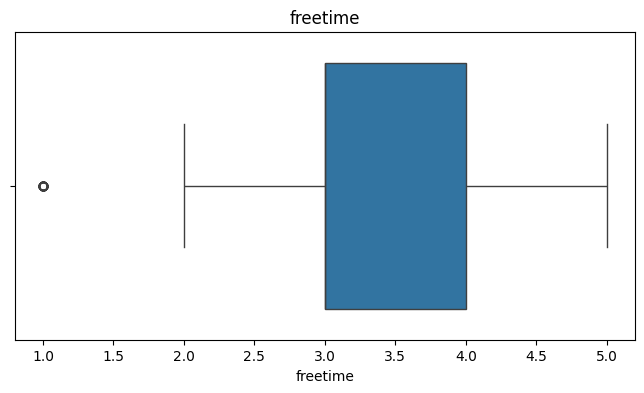

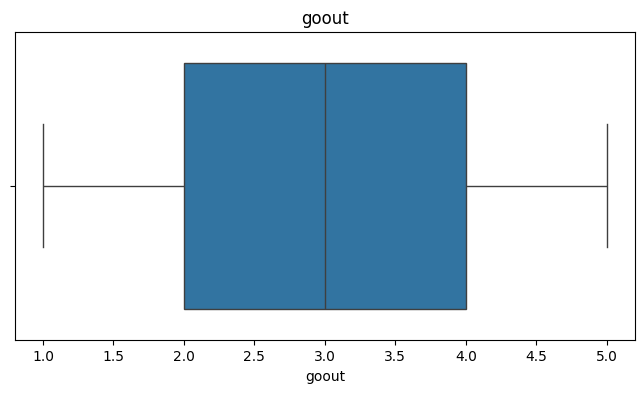

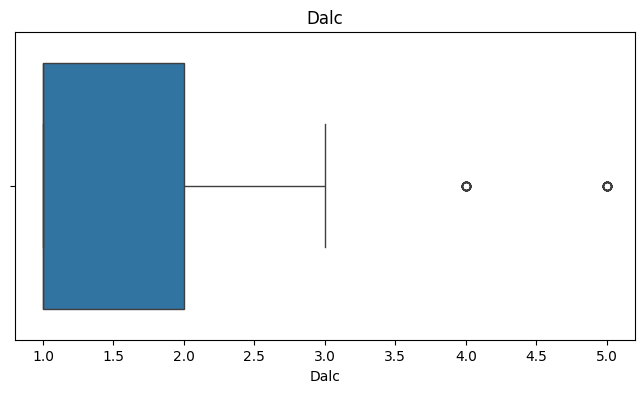

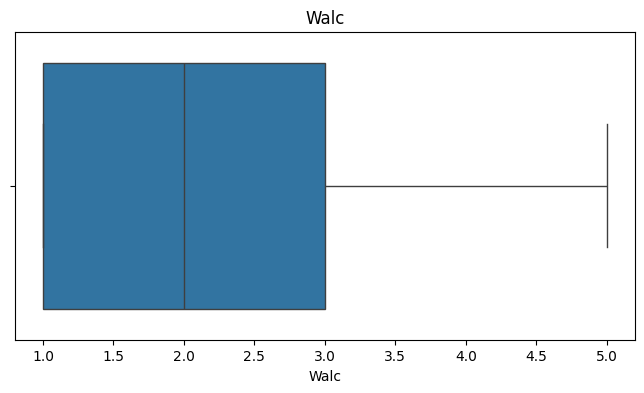

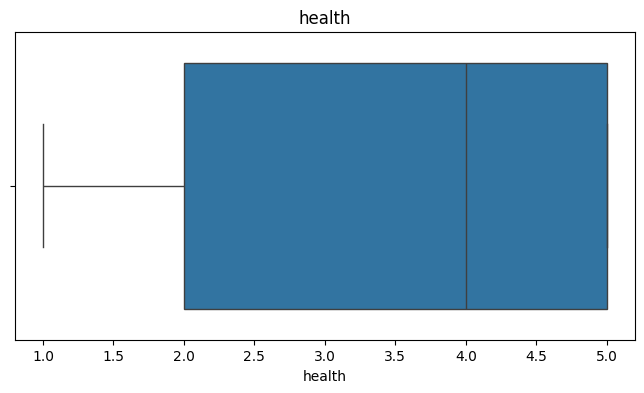

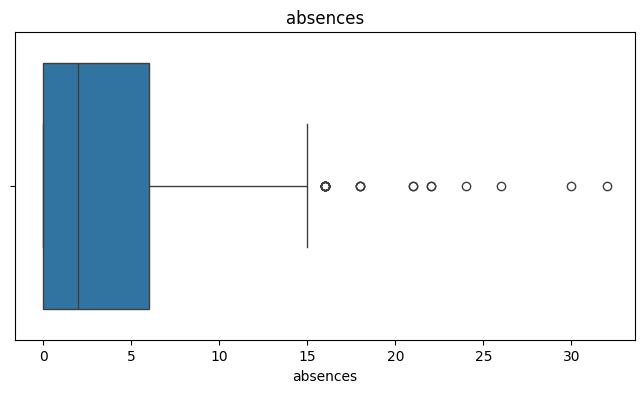

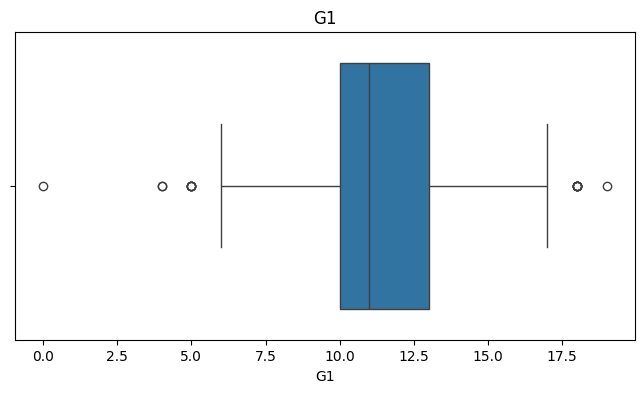

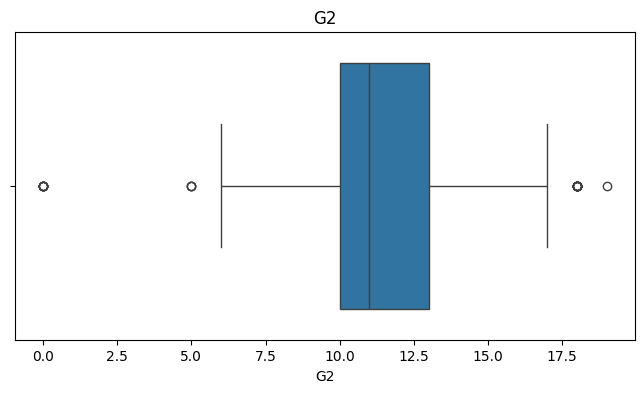

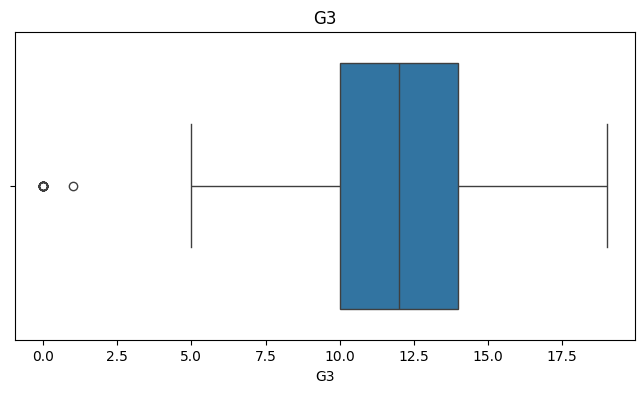

In [ ]:
for col in numeric_cols:
 plt.figure(figsize=(8, 4))
 sns.boxplot(x=df[col])
 plt.title(col)
 plt.show()


 Outlier Treatment (IQR Method)


In [ ]:
for col in numeric_cols:
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 df = df[(df[col] >= lower) & (df[col] <= upper)]

Verify Cleaning


In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 1 to 645
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      268 non-null    object
 1   sex         268 non-null    object
 2   age         268 non-null    int64 
 3   address     268 non-null    object
 4   famsize     268 non-null    object
 5   Pstatus     268 non-null    object
 6   Medu        268 non-null    int64 
 7   Fedu        268 non-null    int64 
 8   Mjob        268 non-null    object
 9   Fjob        268 non-null    object
 10  reason      268 non-null    object
 11  guardian    268 non-null    object
 12  traveltime  268 non-null    int64 
 13  studytime   268 non-null    int64 
 14  failures    268 non-null    int64 
 15  schoolsup   268 non-null    object
 16  famsup      268 non-null    object
 17  paid        268 non-null    object
 18  activities  268 non-null    object
 19  nursery     268 non-null    object
 20  higher      268

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)